## NEP EOS

### without relax

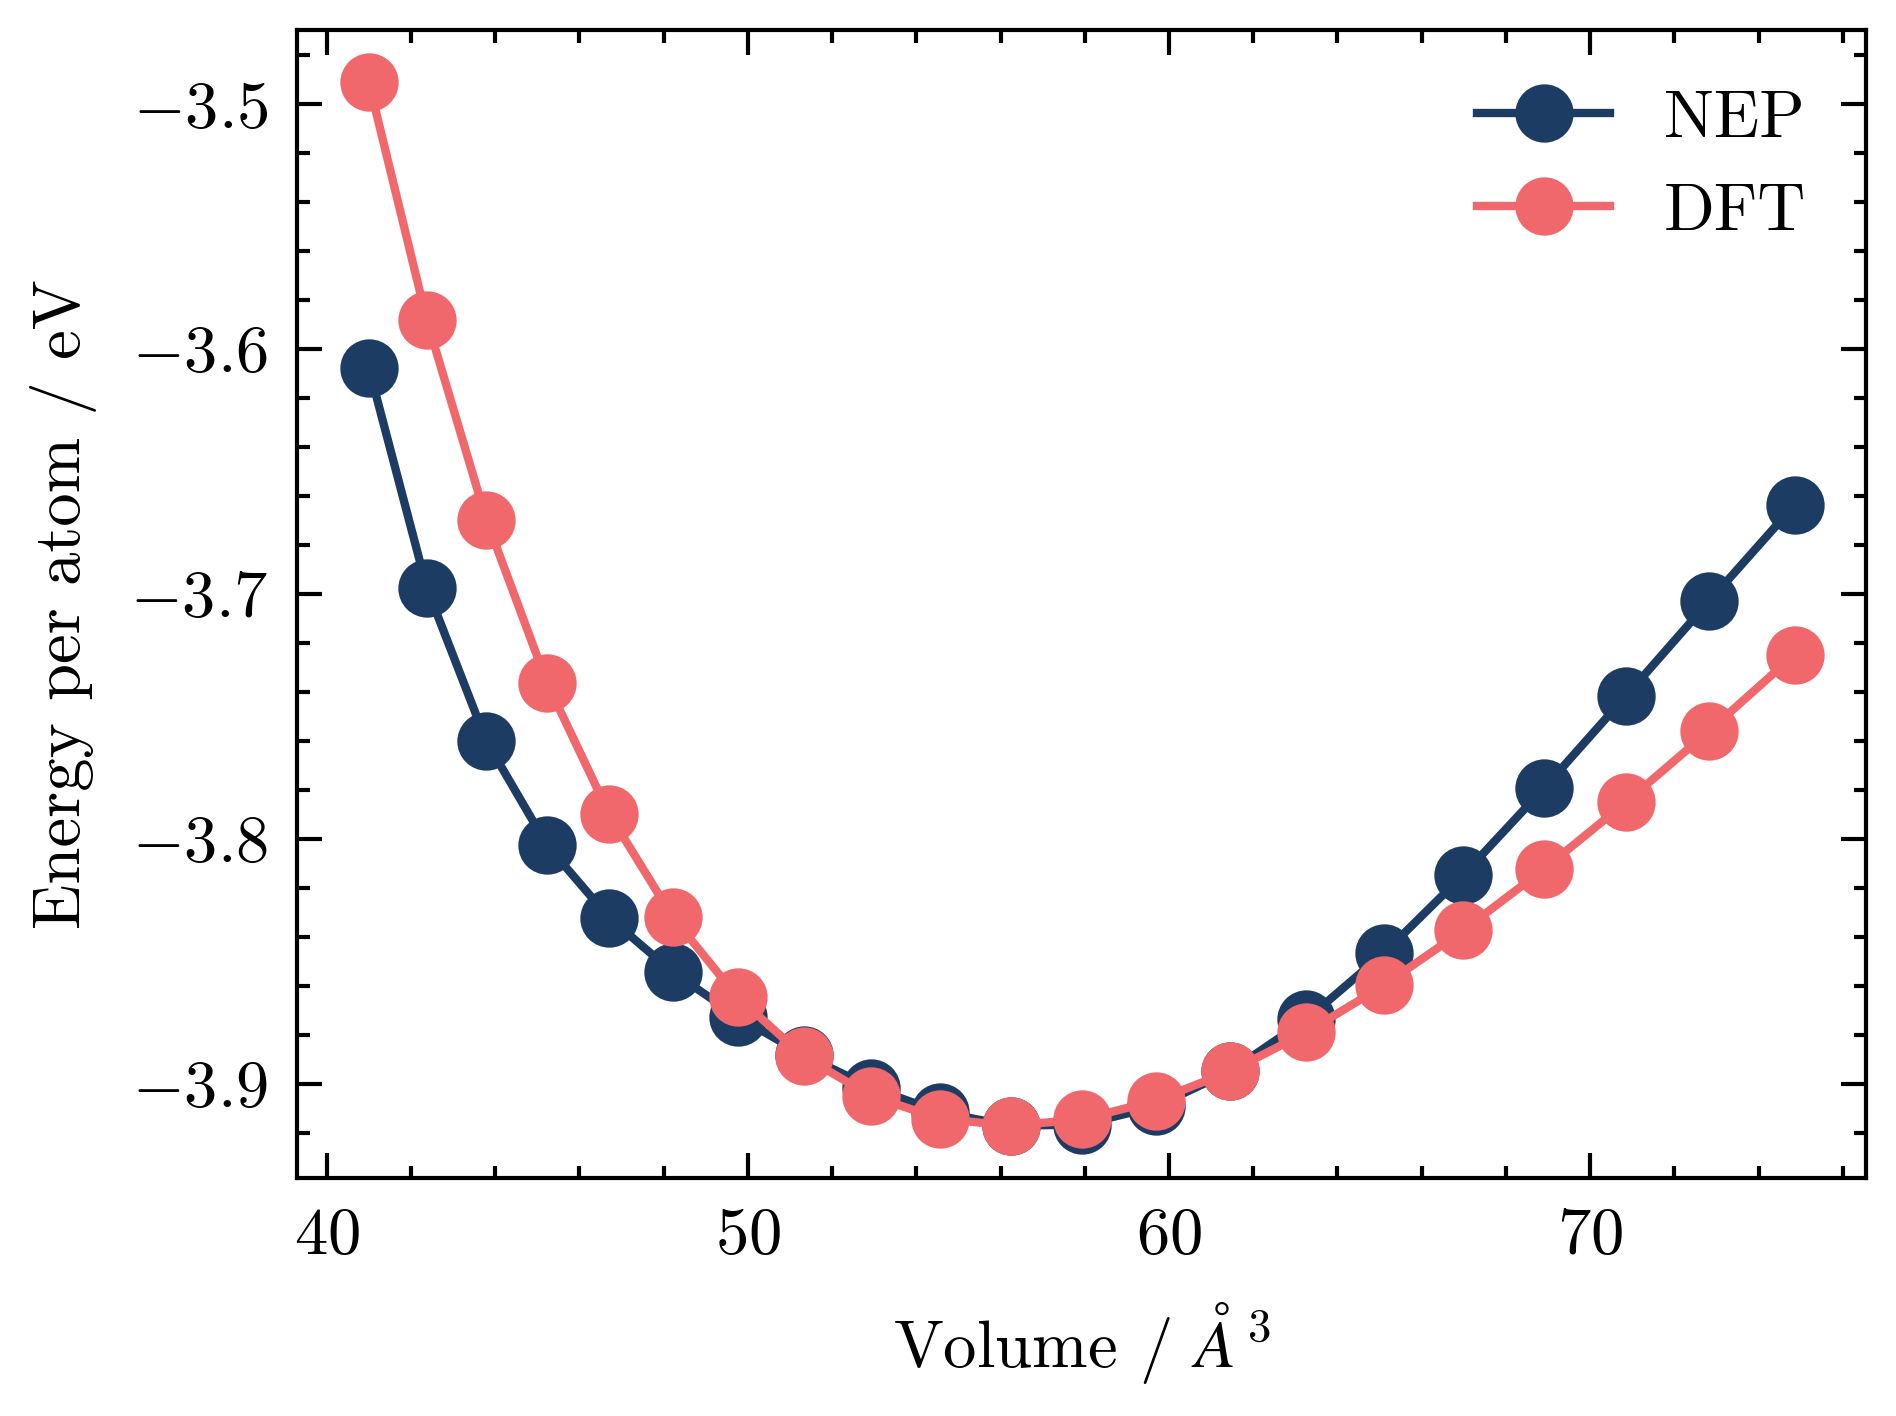

In [11]:
'''
文件名: evbycalorine.py
运行方法: python evbycalorine.py
功能描述: 
'''

import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import scienceplots
import sys
from ase.calculators.mixing import SumCalculator
from ase.io import read, write
from ase.units import GPa
from calorine.calculators import CPUNEP
from calorine.tools import relax_structure
from dftd3.ase import DFTD3

plt.style.use(['science','ieee','no-latex','bright'])
colors = ["#1C3C63", "#F0686C"]
        
def nep_calculator(filename="../nep_NequIP.txt", use_dftd3=False):
    """
    配置NEP计算器，若需色散校正，则use_dftd3=True
    """
    if os.path.exists(filename):
        if use_dftd3:
            return SumCalculator([CPUNEP(filename), DFTD3(method="pbe", damping="d3bj")])
        return CPUNEP(filename)
    print(f"File {filename} does not exist.")
    sys.exit(1)

def extract_energy_per_atom_from_xyz(file_path):
    energy_per_atom_list = []
    with open(file_path, 'r') as file:
        lines = file.readlines()
    i = 0
    while i < len(lines):
        num_atoms = int(lines[i].strip())
        i += 1
        if "energy=" in lines[i]:
            energy_line = lines[i]
            energy_value = float(energy_line.split("energy=")[1].split()[0])
            energy_per_atom = energy_value / num_atoms
            energy_per_atom_list.append(energy_per_atom)
        i += num_atoms + 1
    return energy_per_atom_list
    
ini_path = "./r3m.vasp"
xyz_path = "./r3m.xyz"
structure = read(ini_path)
structure.calc = nep_calculator()

vol, nep = [], []

### RELAX ###
for volsc in np.arange(0.9, 1.1, 0.01):
    s = structure.copy()
    s.cell *= volsc
    # write('scale_{:.2f}.vasp'.format(volsc), s)
    s.calc = nep_calculator()
    # relax_structure(s, constant_volume=True)
    vol.append(s.get_volume())
    nep.append(s.get_potential_energy() / len(structure))
### ----- ###
    
dft = extract_energy_per_atom_from_xyz(xyz_path)

vol = np.array(vol)
nep = np.array(nep)
dft = np.array(dft)

delta = np.min(dft) - np.min(nep) 
nep = nep + delta

plt.figure()
plt.plot(vol, nep, 'o-', c=colors[0], label='NEP')
plt.plot(vol, dft, 'o-', c=colors[1], label="DFT")

plt.xlabel('Volume / $Å^3$')
plt.ylabel('Energy per atom / eV')
plt.legend(loc="best")
plt.tight_layout()
plt.savefig('./ev.png', bbox_inches='tight')

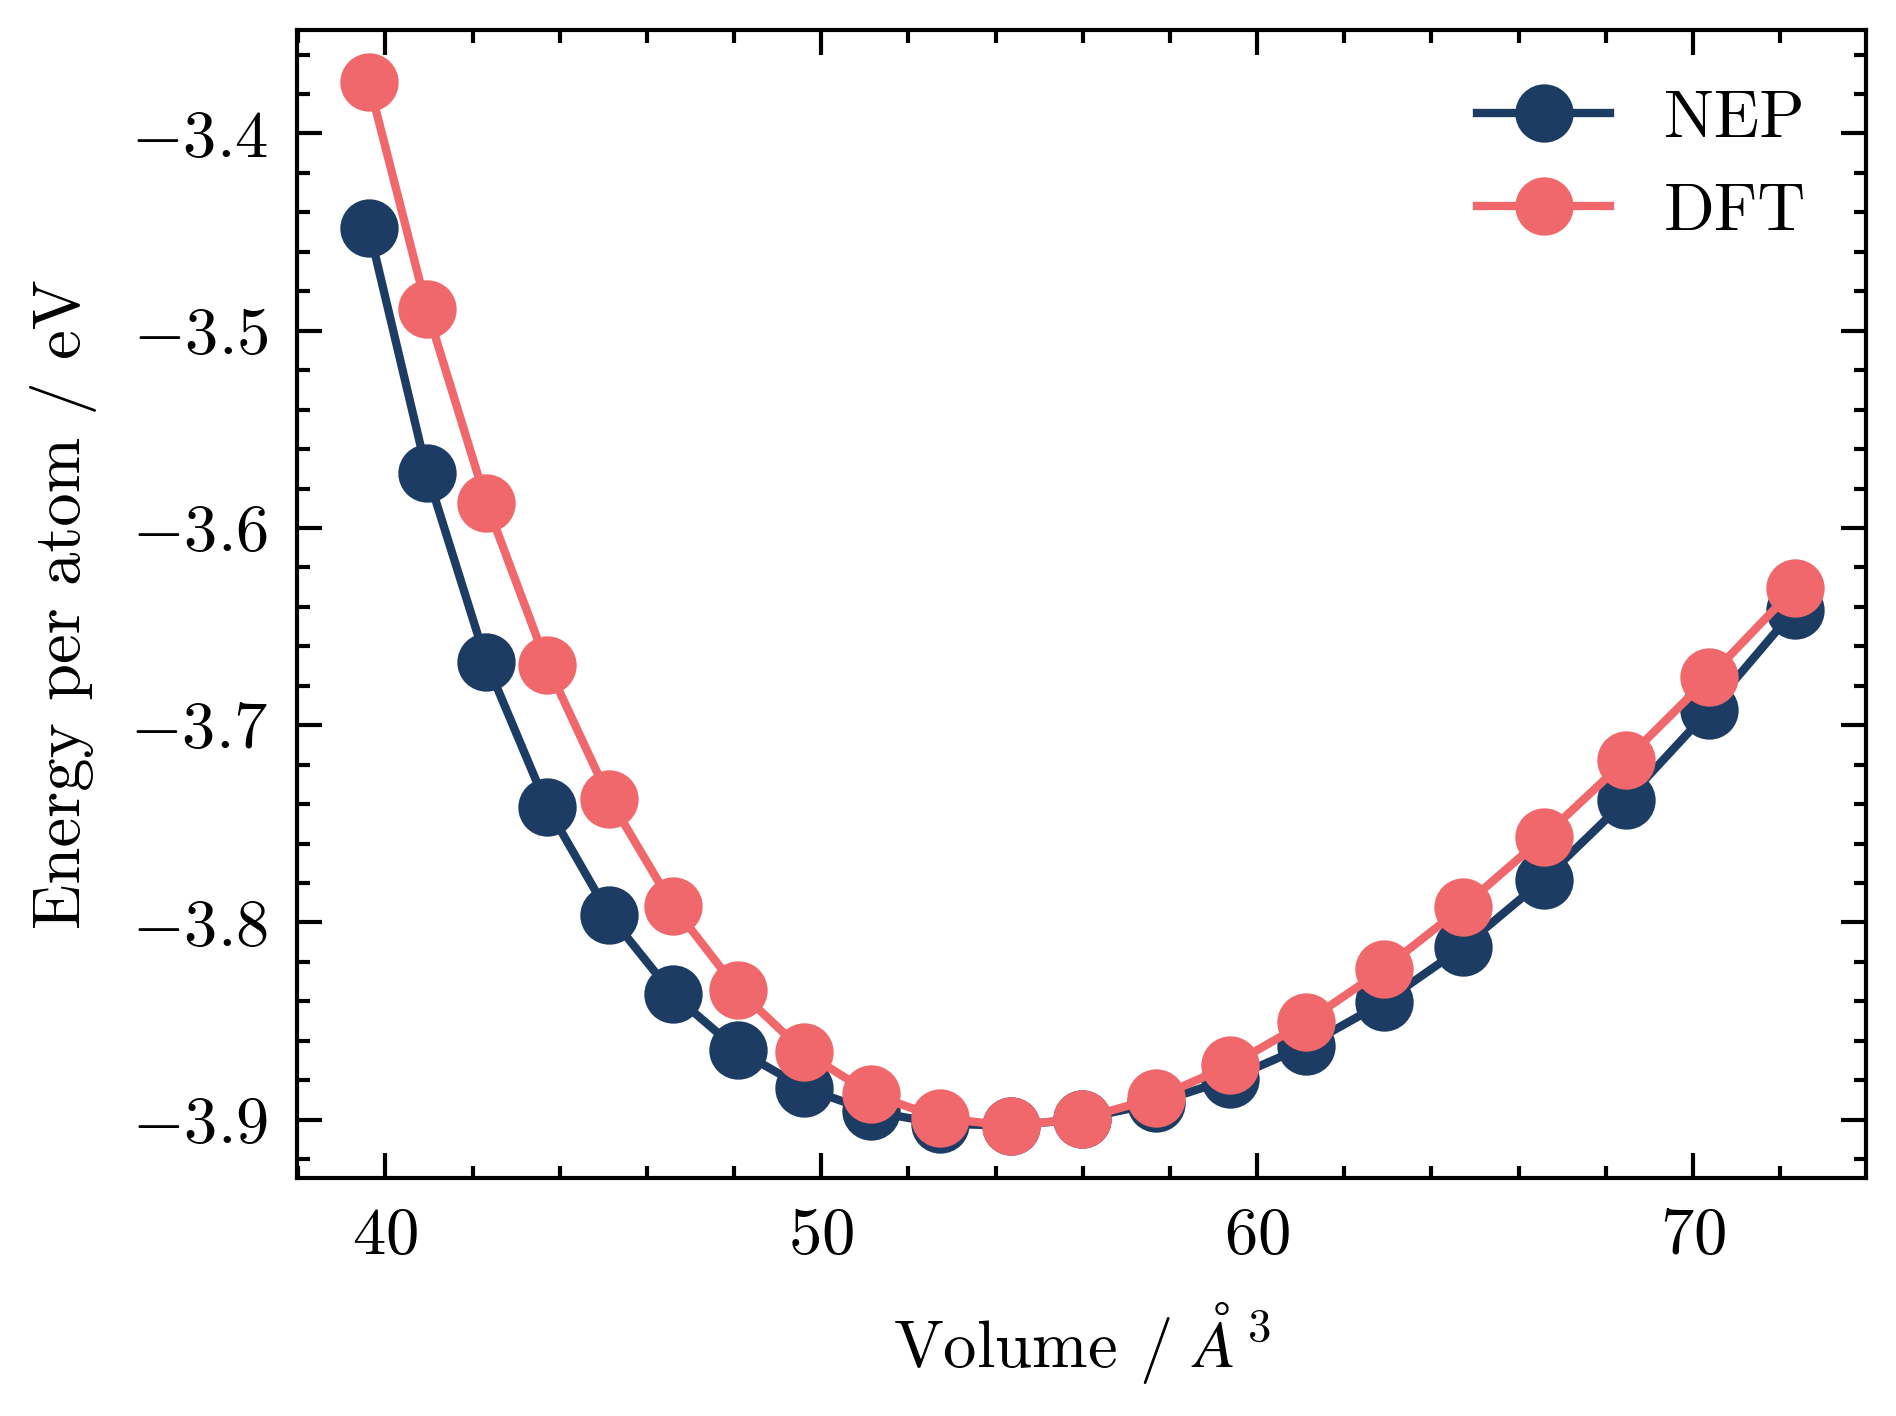

In [10]:
ini_path = "./fm-3m.vasp"
xyz_path = "./fm-3m.xyz"
structure = read(ini_path)
structure.calc = nep_calculator()

vol, nep = [], []

### RELAX ###
for volsc in np.arange(0.9, 1.1, 0.01):
    s = structure.copy()
    s.cell *= volsc
    # write('scale_{:.2f}.vasp'.format(volsc), s)
    s.calc = nep_calculator()
    # relax_structure(s, constant_volume=True)
    vol.append(s.get_volume())
    nep.append(s.get_potential_energy() / len(structure))
### ----- ###
    
dft = extract_energy_per_atom_from_xyz(xyz_path)

vol = np.array(vol)
nep = np.array(nep)
dft = np.array(dft)

delta = np.min(dft) - np.min(nep) 
nep = nep + delta

plt.figure()
plt.plot(vol, nep, 'o-', c=colors[0], label='NEP')
plt.plot(vol, dft, 'o-', c=colors[1], label="DFT")

plt.xlabel('Volume / $Å^3$')
plt.ylabel('Energy per atom / eV')
plt.legend(loc="best")
plt.tight_layout()
plt.savefig('./ev.png', bbox_inches='tight')

### relax

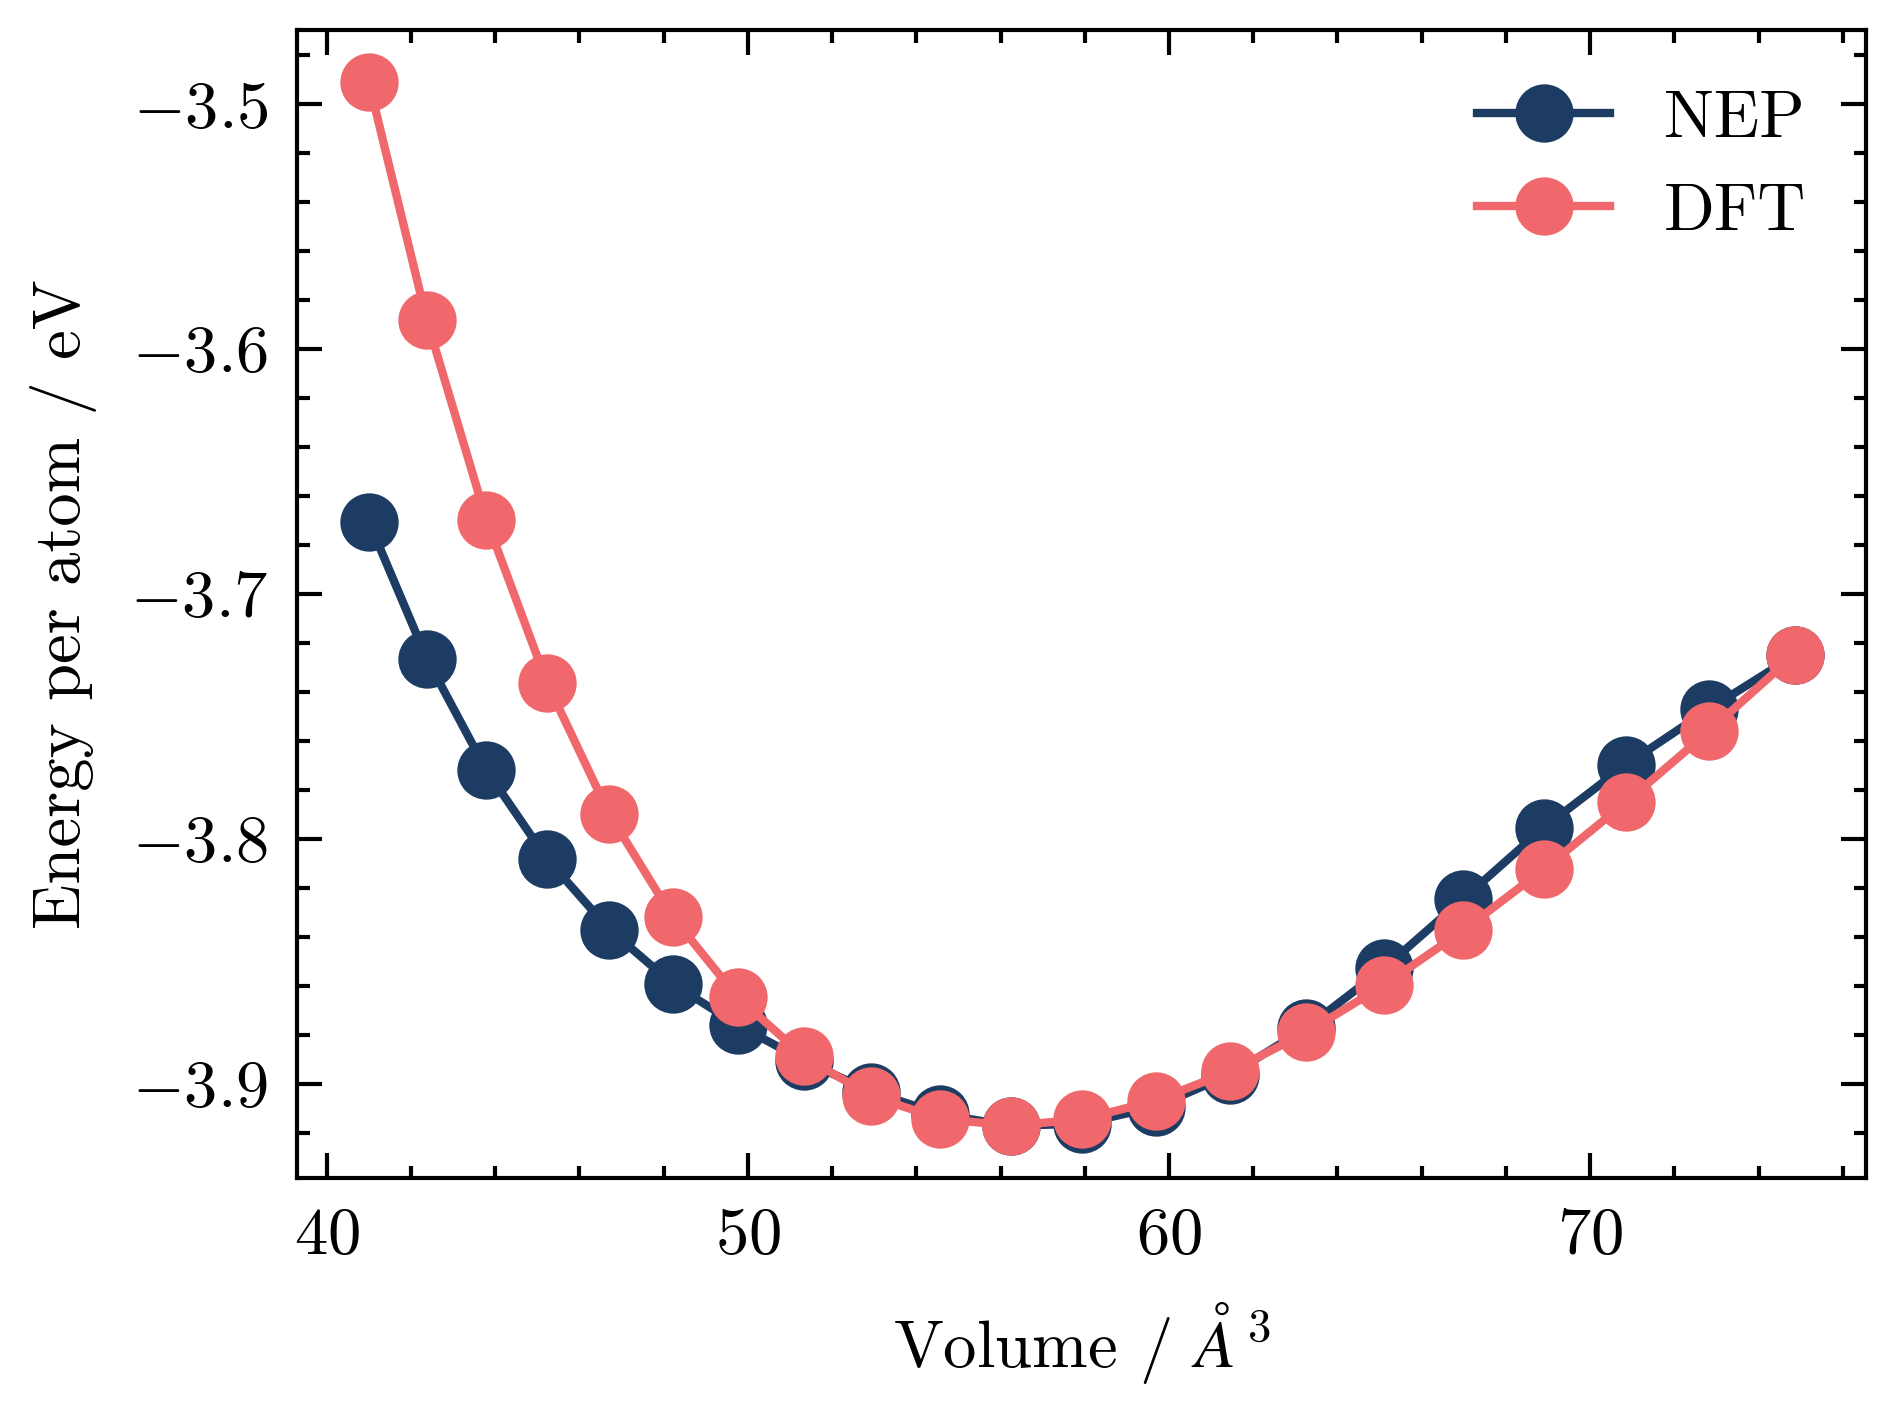

In [3]:
ini_path = "./r3m.vasp"
xyz_path = "./r3m.xyz"
structure = read(ini_path)
structure.calc = nep_calculator()

vol, nep = [], []

### RELAX ###
for volsc in np.arange(0.9, 1.1, 0.01):
    s = structure.copy()
    s.cell *= volsc
    # write('scale_{:.2f}.vasp'.format(volsc), s)
    s.calc = nep_calculator()
    relax_structure(s, constant_volume=True)
    vol.append(s.get_volume())
    nep.append(s.get_potential_energy() / len(structure))
### ----- ###
    
dft = extract_energy_per_atom_from_xyz(xyz_path)

vol = np.array(vol)
nep = np.array(nep)
dft = np.array(dft)

delta = np.min(dft) - np.min(nep) 
nep = nep + delta

plt.figure()
plt.plot(vol, nep, 'o-', c=colors[0], label='NEP')
plt.plot(vol, dft, 'o-', c=colors[1], label="DFT")

plt.xlabel('Volume / $Å^3$')
plt.ylabel('Energy per atom / eV')
plt.legend(loc="best")
plt.tight_layout()
plt.savefig('./ev.png', bbox_inches='tight')

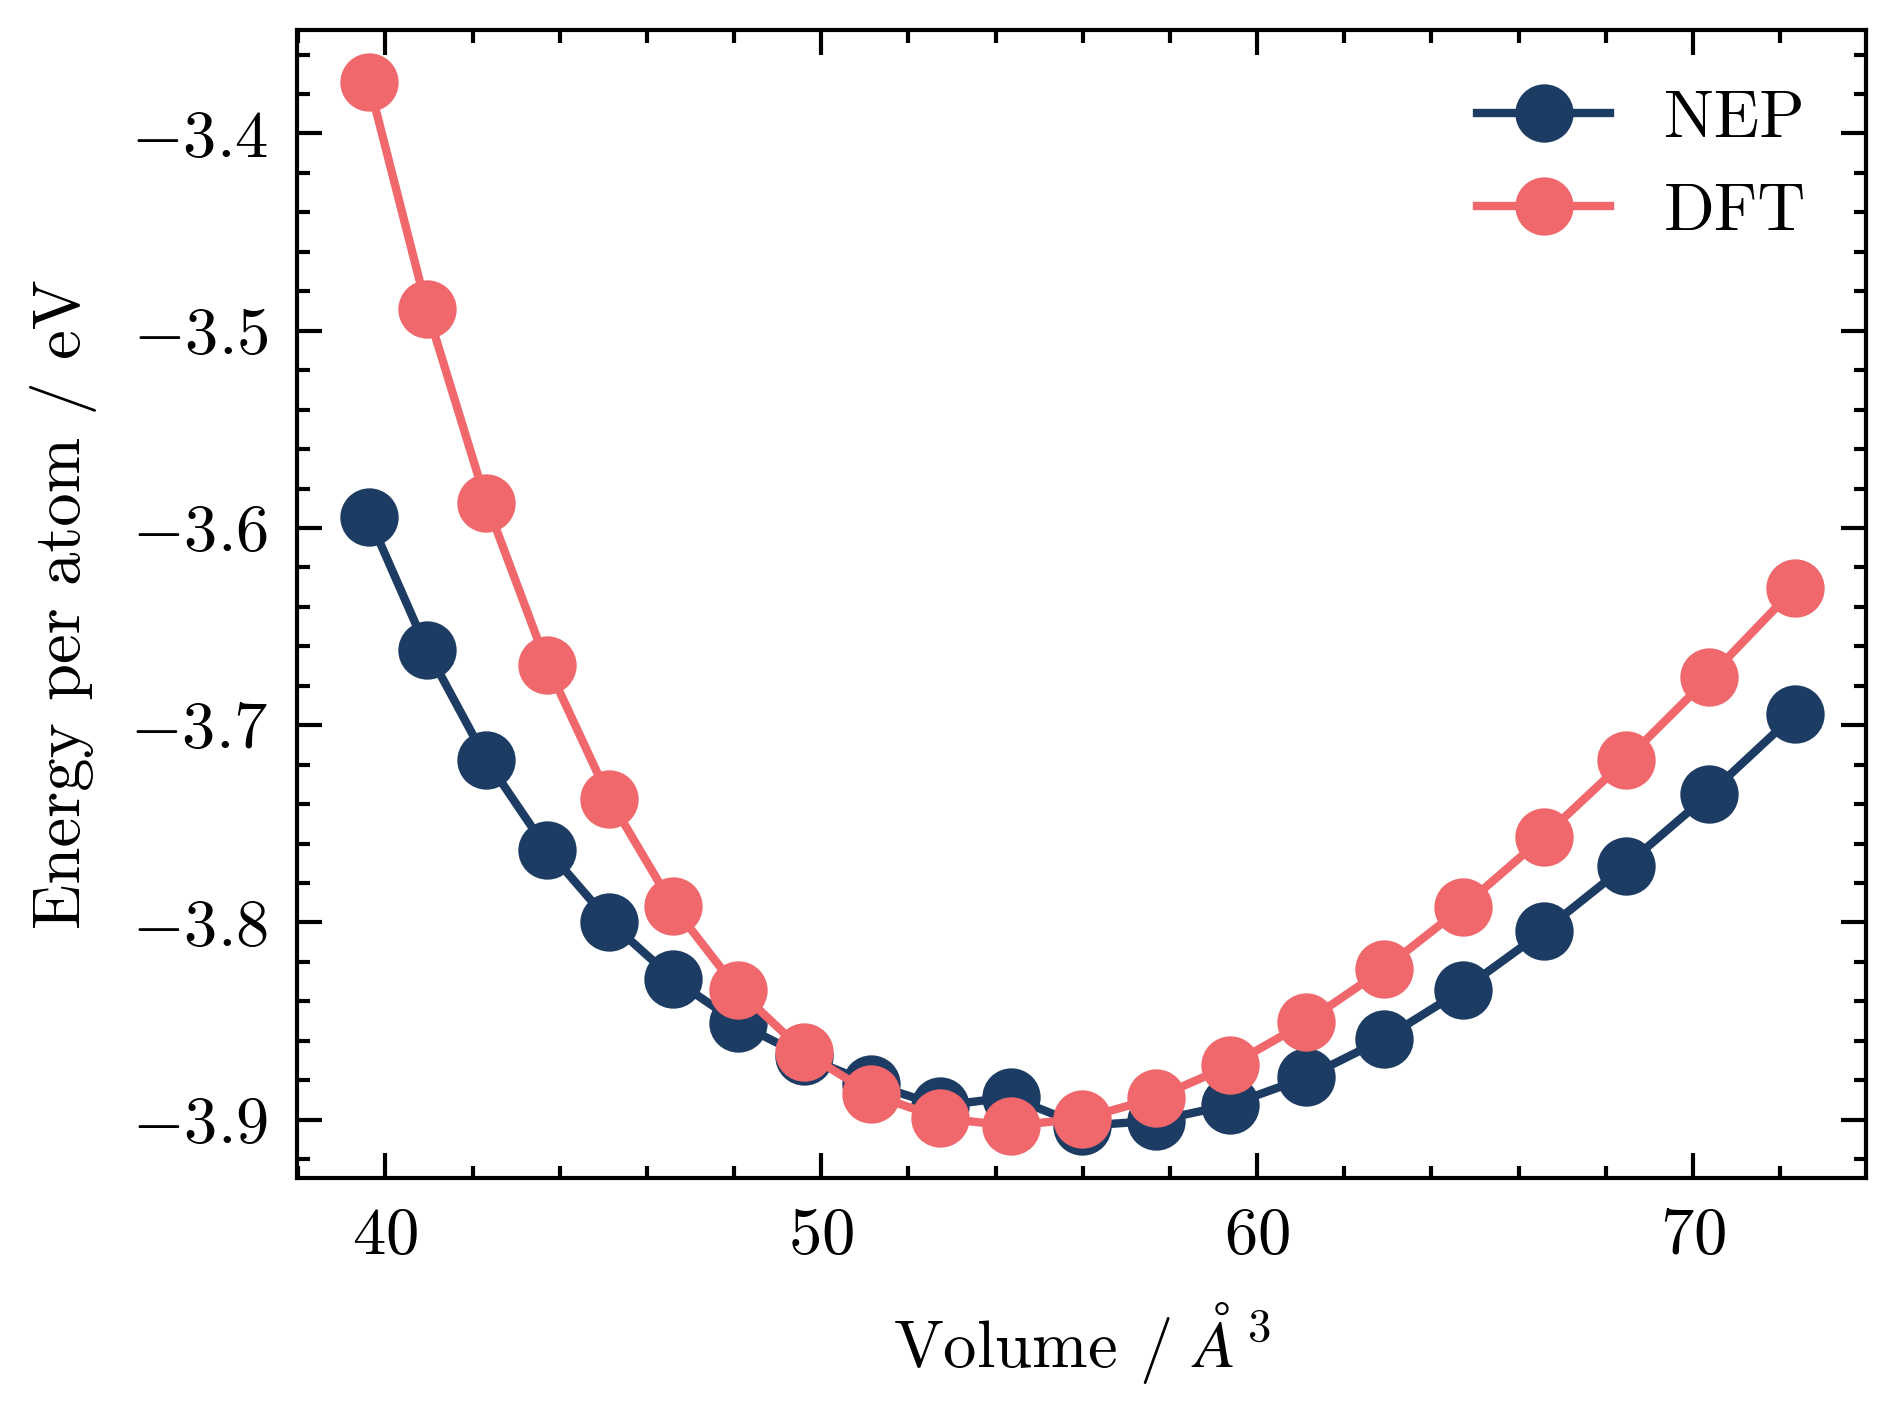

In [4]:
ini_path = "./fm-3m.vasp"
xyz_path = "./fm-3m.xyz"
structure = read(ini_path)
structure.calc = nep_calculator()

vol, nep = [], []

### RELAX ###
for volsc in np.arange(0.9, 1.1, 0.01):
    s = structure.copy()
    s.cell *= volsc
    # write('scale_{:.2f}.vasp'.format(volsc), s)
    s.calc = nep_calculator()
    relax_structure(s, constant_volume=True)
    vol.append(s.get_volume())
    nep.append(s.get_potential_energy() / len(structure))
### ----- ###
    
dft = extract_energy_per_atom_from_xyz(xyz_path)

vol = np.array(vol)
nep = np.array(nep)
dft = np.array(dft)

delta = np.min(dft) - np.min(nep) 
nep = nep + delta

plt.figure()
plt.plot(vol, nep, 'o-', c=colors[0], label='NEP')
plt.plot(vol, dft, 'o-', c=colors[1], label="DFT")

plt.xlabel('Volume / $Å^3$')
plt.ylabel('Energy per atom / eV')
plt.legend(loc="best")
plt.tight_layout()
plt.savefig('./ev.png', bbox_inches='tight')